DATA LOADING AND PROCESSING

C:\Users\tavis\Downloads\archive (1)
month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64
Order Date
2014-01-31     14236.8950
2014-02-28      4519.8920
2014-03-31     55691.0090
2014-04-30     28295.3450
2014-05-31     23648.2870
2014-06-30     34595.1276
2014-07-31     33946.3930
2014-08-31     27909.4685
2014-09-30     81777.3508
2014-10-31     31453.3930
2014-11-30     78628.7167
2014-12-31     69545.6205
2015-01-31     18174.0756
2015-02-28     11951.4110
2015-03-31     38726.2520
2015-04-30     34195.2085
2015-05-31     30131.6865
2015-06-30     24797.2920
2015-07-31     28765.3250
2015-08-31     36898.3322
2015-09-30     64595.9180
2015-10-31     31404.9235
2015-11-30     75972.5635
2015-12-31     74919.5212
2016-01-31     18542.4910
2016-02-29     22978.8150
2016-03-31     51715.8750


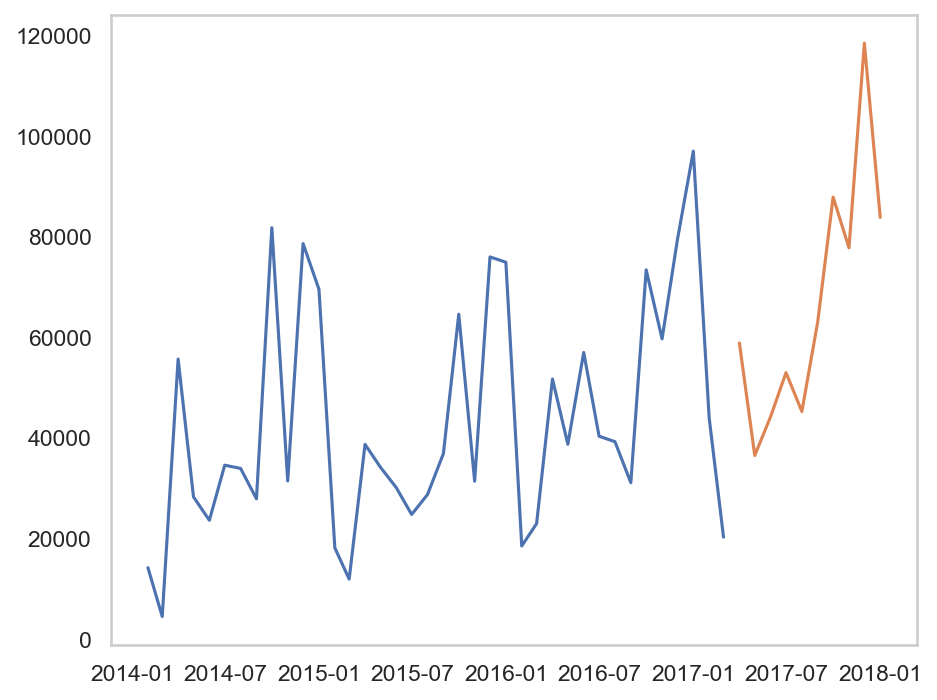

In [33]:

import zipfile

with zipfile.ZipFile(r'C:/Users/tavis/Downloads/archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall(r'C:/Users/tavis/Downloads/archive (1)')
    %cd C:\Users\tavis\Downloads\archive (1)
import pandas as pd
df=pd.read_csv("C:/Users/tavis\Downloads/archive (1)/Sample - Superstore.csv", encoding='ISO-8859-1')

df
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['month']=df['Order Date'].dt.month
df
results=df.groupby('month')['Sales'].sum()
print(results)

monthly=df.resample('ME', on='Order Date')['Sales'].sum()
print(monthly)


from matplotlib import pyplot as plt

split = int(len(monthly) * 0.8)
train = monthly[:split]
plt.plot(train)
test = monthly[split:]
plt.plot(test)
plt.tight_layout()
plt.grid()
plt.show()

BUILDING LAG FEATURES

In [34]:
df_ml = monthly.reset_index()
df_ml['lag_1'] = df_ml['Sales'].shift(1)
df_ml['lag_2'] = df_ml['Sales'].shift(2)
df_ml['lag_4'] = df_ml['Sales'].shift(4)
df_ml['lag_12'] = df_ml['Sales'].shift(12)

BUILDING ROLLING FEATURES

In [35]:
df_ml['roll_mean_4'] = df_ml['Sales'].rolling(4).mean()
df_ml['roll_std_4'] = df_ml['Sales'].rolling(4).std()
df_ml['roll_mean_12'] = df_ml['Sales'].rolling(12).mean()

In [36]:
df_ml['month'] = df_ml['Order Date'].dt.month
df_ml['quarter'] = df_ml['Order Date'].dt.quarter
df_ml['week'] = df_ml['Order Date'].dt.isocalendar().week
df_ml['holiday_flag'] = 0 # set to 1 for Diwali/Christmas weeks manually
df_ml = df_ml.dropna()
print(df_ml.head())

   Order Date       Sales       lag_1       lag_2       lag_4     lag_12  \
12 2015-01-31  18174.0756  69545.6205  78628.7167  81777.3508  14236.895   
13 2015-02-28  11951.4110  18174.0756  69545.6205  31453.3930   4519.892   
14 2015-03-31  38726.2520  11951.4110  18174.0756  78628.7167  55691.009   
15 2015-04-30  34195.2085  38726.2520  11951.4110  69545.6205  28295.345   
16 2015-05-31  30131.6865  34195.2085  38726.2520  18174.0756  23648.287   

     roll_mean_4    roll_std_4  roll_mean_12  month  quarter  week  \
12  49450.451450  29196.419765  40682.056558      1        1     5   
13  44574.955950  34372.929647  41301.349808      2        1     9   
14  34599.339775  25955.037546  39887.620058      3        1    14   
15  25761.736775  12747.546175  40379.275350      4        2    18   
16  28751.139500  11737.085731  40919.558642      5        2    22   

    holiday_flag  
12             0  
13             0  
14             0  
15             0  
16             0  


In [37]:
features = ['lag_1','lag_2','lag_4','lag_12','roll_mean_4','roll_std_4','roll_mean_12','month','quarter','week','holiday_flag']
X = df_ml[features]
y = df_ml['Sales']
split = int(len(df_ml)*0.8)
X_train,X_test = X[:split],X[split:]
y_train,y_test = y[:split],y[split:]


In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
def evaluate(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual-predicted)/actual))*100
    return {'RMSE':round(rmse,2), 'MAE':round(mae,2), 'MAPE':round(mape,2)}

from xgboost import XGBRegressor
model_xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)

xgb_metrics = evaluate(y_test.values, pred_xgb)
results['XGBoost'] = xgb_metrics
print(results)


month
1                                                 94924.8356
2                                                 59751.2514
3                                                205005.4888
4                                                137762.1286
5                                                155028.8117
6                                                152718.6793
7                                                 147238.097
8                                                 159044.063
9                                                307649.9457
10                                               200322.9847
11                                                352461.071
12                                               325293.5035
XGBoost    {'RMSE': 16364.5, 'MAE': 13418.58, 'MAPE': 17.84}
Name: Sales, dtype: object


In [39]:


df_ml['rolling_mean_4'] = df_ml['Sales'].rolling(window=4).mean()


 FEATURE IMPORTANCE + HOLIDAY EXPERIMENT


   Order Date       Sales       lag_1       lag_2       lag_4     lag_12  \
12 2015-01-31  18174.0756  69545.6205  78628.7167  81777.3508  14236.895   
13 2015-02-28  11951.4110  18174.0756  69545.6205  31453.3930   4519.892   
14 2015-03-31  38726.2520  11951.4110  18174.0756  78628.7167  55691.009   
15 2015-04-30  34195.2085  38726.2520  11951.4110  69545.6205  28295.345   
16 2015-05-31  30131.6865  34195.2085  38726.2520  18174.0756  23648.287   

     roll_mean_4    roll_std_4  roll_mean_12  month  quarter  week  \
12  49450.451450  29196.419765  40682.056558      1        1     5   
13  44574.955950  34372.929647  41301.349808      2        1     9   
14  34599.339775  25955.037546  39887.620058      3        1    14   
15  25761.736775  12747.546175  40379.275350      4        2    18   
16  28751.139500  11737.085731  40919.558642      5        2    22   

    holiday_flag  rolling_mean_4  
12             0             NaN  
13             0             NaN  
14             0 

<Figure size 1500x900 with 0 Axes>

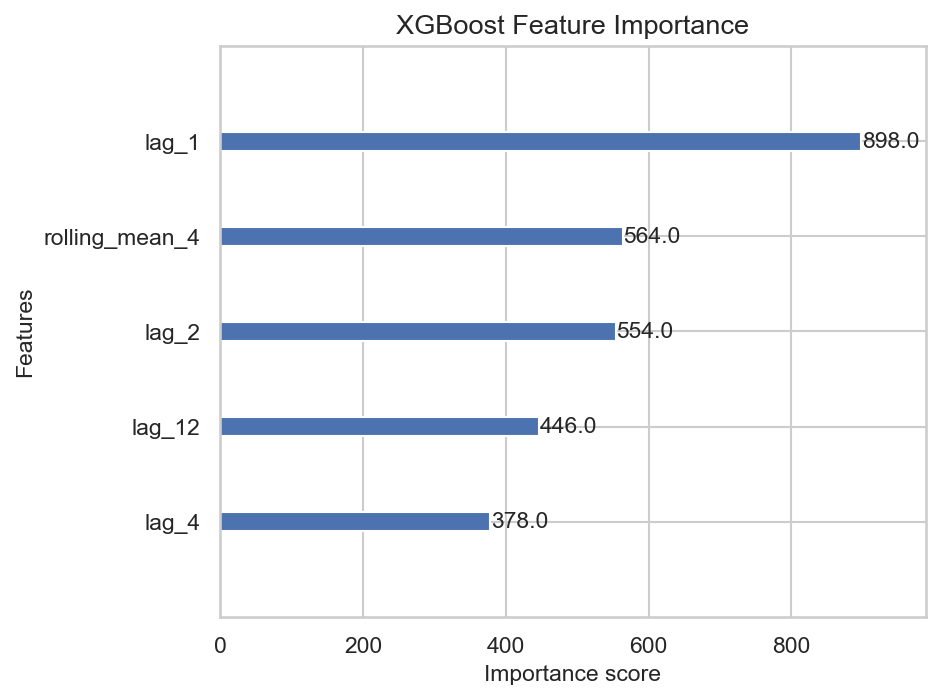


Feature importance figure saved as:
fig_feature_importance.png


In [40]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_absolute_percentage_error



print(df_ml.head())
print(df_ml.columns)



df_ml = df_ml.dropna().copy()



features_with_holiday = [
    'lag_1',
    'lag_2',
    'lag_4',
    'lag_12',
    'rolling_mean_4',
    'holiday_flag'
]

features_without_holiday = [
    'lag_1',
    'lag_2',
    'lag_4',
    'lag_12',
    'rolling_mean_4'
]



split_index = int(len(df_ml) * 0.8)

train = df_ml.iloc[:split_index]
test = df_ml.iloc[split_index:]


 #MODEL 1 : WITHOUT HOLIDAY FLAG


X_train_no = train[features_without_holiday]
X_test_no = test[features_without_holiday]
TARGET= 'Sales'
y_train = train[TARGET]
y_test = test[TARGET]

model_no_holiday = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

model_no_holiday.fit(X_train_no, y_train)

pred_no_holiday = model_no_holiday.predict(X_test_no)

mape_no_holiday = mean_absolute_percentage_error(
    y_test,
    pred_no_holiday
) * 100

print("\nMAPE WITHOUT HOLIDAY FLAG:")
print(round(mape_no_holiday, 2), "%")

# MODEL 2 : WITH HOLIDAY FLAG


X_train_yes = train[features_with_holiday]
X_test_yes = test[features_with_holiday]

model_with_holiday = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

model_with_holiday.fit(X_train_yes, y_train)

pred_with_holiday = model_with_holiday.predict(X_test_yes)

mape_with_holiday = mean_absolute_percentage_error(
    y_test,
    pred_with_holiday
) * 100

print("\nMAPE WITH HOLIDAY FLAG:")
print(round(mape_with_holiday, 2), "%")



improvement = mape_no_holiday - mape_with_holiday

print("\nIMPROVEMENT AFTER ADDING HOLIDAY FLAG:")
print(round(improvement, 2), "%")


plt.figure(figsize=(10,6))

plot_importance(
    model_with_holiday,
    max_num_features=10,
    importance_type='weight'
)

plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.savefig("fig_feature_importance.png", dpi=300)

plt.show()

print("\nFeature importance figure saved as:")
print("fig_feature_importance.png")


 HYPERPARAMETER TUNING + COMPARISON CHART


n_estimators=100, max_depth=3 --> MAPE=15.24%
n_estimators=100, max_depth=5 --> MAPE=16.0%
n_estimators=100, max_depth=7 --> MAPE=18.25%
n_estimators=300, max_depth=3 --> MAPE=13.87%
n_estimators=300, max_depth=5 --> MAPE=15.6%
n_estimators=300, max_depth=7 --> MAPE=18.2%
n_estimators=500, max_depth=3 --> MAPE=13.81%
n_estimators=500, max_depth=5 --> MAPE=15.6%
n_estimators=500, max_depth=7 --> MAPE=18.2%

BEST PARAMETERS:
n_estimators = 500
max_depth = 3

BEST MAPE:
13.81 %


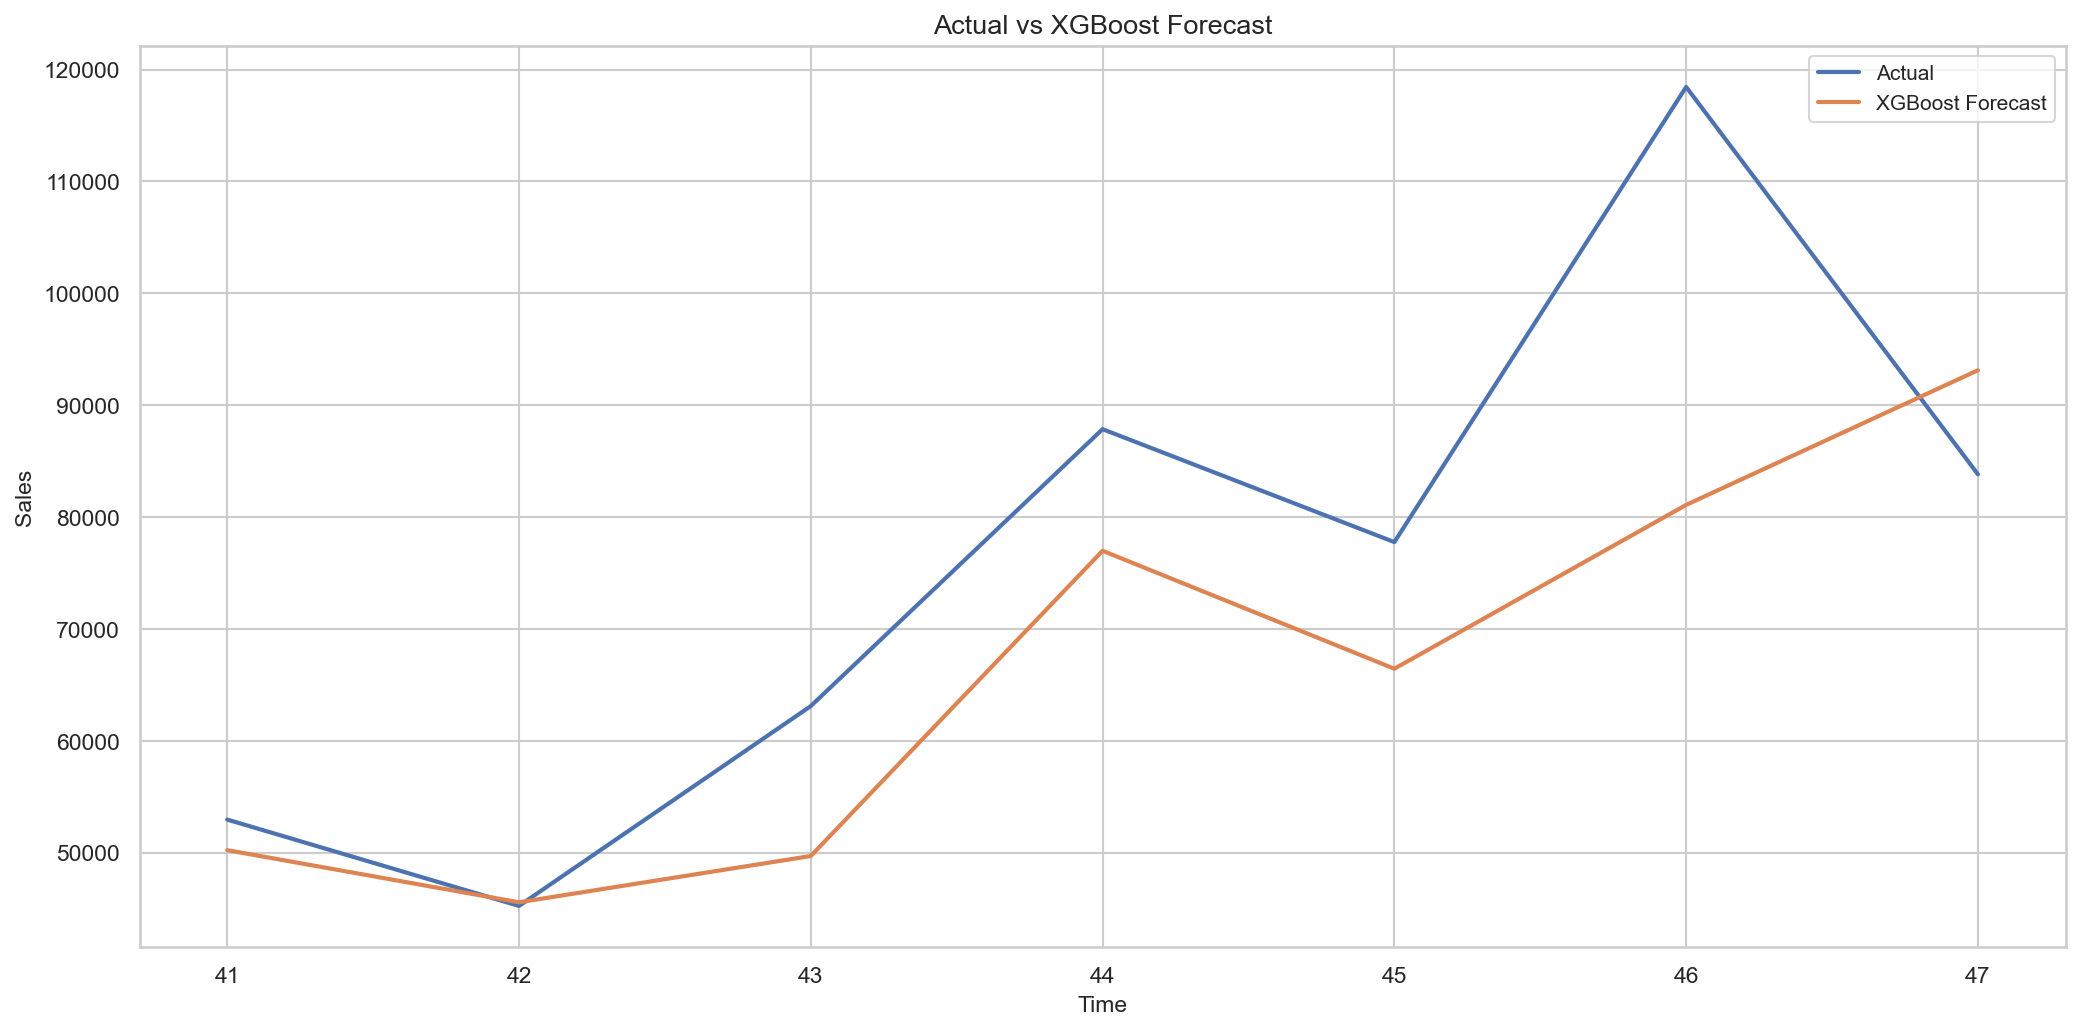


Comparison chart saved as:
fig_four_model_compare.png

TUNING RESULTS:
   n_estimators  max_depth   MAPE
0           100          3  15.24
1           100          5  16.00
2           100          7  18.25
3           300          3  13.87
4           300          5  15.60
5           300          7  18.20
6           500          3  13.81
7           500          5  15.60
8           500          7  18.20


In [41]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error



TARGET = 'Sales'

features = [
    'lag_1',
    'lag_2',
    'lag_4',
    'lag_12',
    'rolling_mean_4',
    'holiday_flag'
]



split_index = int(len(df_ml) * 0.8)

train = df_ml.iloc[:split_index]
test = df_ml.iloc[split_index:]

X_train = train[features]
X_test = test[features]

y_train = train[TARGET]
y_test = test[TARGET]


# HYPERPARAMETER TUNING


n_estimators_list = [100, 300, 500]
max_depth_list = [3, 5, 7]

results = []

best_mape = 999
best_model = None
best_params = None

for n_est in n_estimators_list:
    
    for depth in max_depth_list:
        
        model = XGBRegressor(
            n_estimators=n_est,
            max_depth=depth,
            learning_rate=0.05,
            random_state=42
        )
        
        model.fit(X_train, y_train)
        
        preds = model.predict(X_test)
        
        mape = mean_absolute_percentage_error(
            y_test,
            preds
        ) * 100
        
        results.append({
            'n_estimators': n_est,
            'max_depth': depth,
            'MAPE': round(mape, 2)
        })
        
        print(f"n_estimators={n_est}, max_depth={depth} --> MAPE={round(mape,2)}%")
        
        if mape < best_mape:
            best_mape = mape
            best_model = model
            best_params = (n_est, depth)


# BEST MODEL


print("\nBEST PARAMETERS:")
print("n_estimators =", best_params[0])
print("max_depth =", best_params[1])

print("\nBEST MAPE:")
print(round(best_mape, 2), "%")


# FINAL PREDICTIONS


final_preds = best_model.predict(X_test)



plt.figure(figsize=(14,7))

plt.plot(
    test.index,
    y_test,
    label='Actual',
    linewidth=2
)

plt.plot(
    test.index,
    final_preds,
    label='XGBoost Forecast',
    linewidth=2
)



plt.title("Actual vs XGBoost Forecast")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("fig_four_model_compare.png", dpi=300)

plt.show()

print("\nComparison chart saved as:")
print("fig_four_model_compare.png")



results_df = pd.DataFrame(results)

print("\nTUNING RESULTS:")
print(results_df)